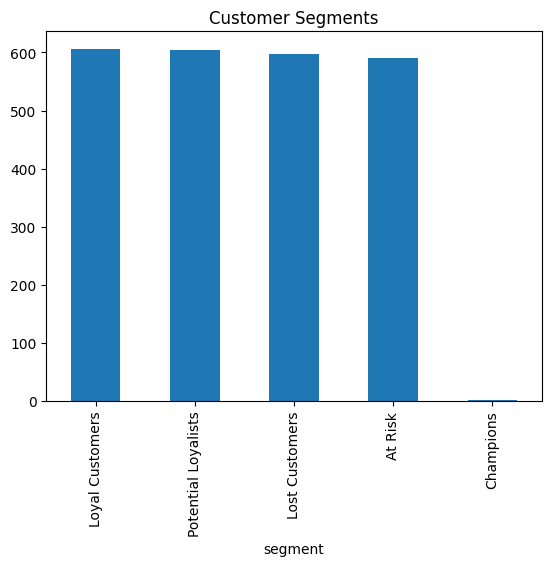

In [16]:
rfm['segment'].value_counts().plot(kind='bar')
plt.title('Customer Segments')
plt.show()

In [15]:
rfm['segment'] = rfm['RFM_score'].apply(segment_customer)

rfm['segment'].value_counts()

segment
Loyal Customers        606
Potential Loyalists    605
Lost Customers         598
At Risk                590
Champions                1
Name: count, dtype: int64

In [14]:
def segment_customer(score):

    score = int(score)

    if score >= 444:
        return "Champions"

    elif score >= 344:
        return "Loyal Customers"

    elif score >= 244:
        return "Potential Loyalists"

    elif score >= 144:
        return "At Risk"

    else:
        return "Lost Customers"

In [13]:
rfm['RFM_score'] = (
    rfm['R_score'].astype(str)
    + rfm['F_score'].astype(str)
    + rfm['M_score'].astype(str)
)

rfm[['customer_id',
     'R_score',
     'F_score',
     'M_score',
     'RFM_score']].head()

,customer_id,R_score,F_score,M_score,RFM_score
0,CUST00001,2,1,1,211
1,CUST00002,3,1,2,312
2,CUST00003,1,1,2,112
3,CUST00004,1,1,3,113
4,CUST00005,3,2,4,324


In [12]:
rfm[['R_score','F_score','M_score']].head()

,R_score,F_score,M_score
0,2,1,1
1,3,1,2
2,1,1,2
3,1,1,3
4,3,2,4


In [11]:
rfm['R_score'] = pd.qcut(
    rfm['recency_days'],
    4,
    labels=[4,3,2,1]
)

rfm['F_score'] = pd.cut(
    rfm['frequency_180d'],
    bins=4,
    labels=[1,2,3,4]
)

rfm['M_score'] = pd.qcut(
    rfm['monetary_180d'],
    4,
    labels=[1,2,3,4]
)

In [10]:
rfm['frequency_180d'].value_counts().head(20)

frequency_180d
1    1075
2     579
0     302
3     272
4     111
5      37
6      20
7       3
8       1
Name: count, dtype: int64

In [9]:
rfm['R_score'] = pd.qcut(
    rfm['recency_days'],
    4,
    labels=[4,3,2,1],
    duplicates='drop'
)

rfm['F_score'] = pd.qcut(
    rfm['frequency_180d'],
    4,
    labels=[1,2,3,4],
    duplicates='drop'
)

rfm['M_score'] = pd.qcut(
    rfm['monetary_180d'],
    4,
    labels=[1,2,3,4],
    duplicates='drop'
)

ValueError: Bin labels must be one fewer than the number of bin edges

In [6]:
rfm[['recency_days',
     'frequency_180d',
     'monetary_180d']].describe()

,recency_days,frequency_180d,monetary_180d
count,2400.000000,2400.000000,2400.000000
mean,87.375833,1.594583,1179.763196
std,80.137473,1.184964,1035.900649
min,0.000000,0.000000,0.000000
25%,25.000000,1.000000,449.270000
50%,66.000000,1.000000,911.875000
75%,129.000000,2.000000,1681.510000
max,562.000000,8.000000,6982.410000


In [5]:
rfm.isnull().sum()

customer_id                    0
snapshot_date                  0
city_tier                      0
age_group                      0
acquisition_channel            0
loyalty_tier                1386
preferred_category             0
marketing_consent              0
recency_days                   0
frequency_180d                 0
monetary_180d                  0
return_rate_180d               0
avg_discount_pct_180d          0
avg_rating_180d                0
category_diversity_180d        0
ticket_count_90d               0
negative_ticket_rate_90d       0
avg_resolution_hours_90d       0
days_since_signup              0
sessions_30d                   0
product_views_30d              0
cart_adds_30d                  0
wishlist_adds_30d              0
abandoned_carts_30d            0
email_opens_30d                0
campaign_clicks_30d            0
last_visit_days_ago            0
churn_next_60d                 0
split                          0
dtype: int64

In [4]:
rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               2400 non-null   str    
 1   snapshot_date             2400 non-null   str    
 2   city_tier                 2400 non-null   str    
 3   age_group                 2400 non-null   str    
 4   acquisition_channel       2400 non-null   str    
 5   loyalty_tier              1014 non-null   str    
 6   preferred_category        2400 non-null   str    
 7   marketing_consent         2400 non-null   str    
 8   recency_days              2400 non-null   int64  
 9   frequency_180d            2400 non-null   int64  
 10  monetary_180d             2400 non-null   float64
 11  return_rate_180d          2400 non-null   float64
 12  avg_discount_pct_180d     2400 non-null   float64
 13  avg_rating_180d           2400 non-null   float64
 14  category_diversity_

In [3]:
rfm.head()

,customer_id,snapshot_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,marketing_consent,recency_days,frequency_180d,...,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,churn_next_60d,split
0,CUST00001,2025-09-30,Tier 1,18-24,Instagram,Silver,Makeup,Yes,107,1,...,1,4,0,0,0,2,0,20,1,train
1,CUST00002,2025-09-30,Tier 2,25-34,Marketplace,Silver,Hair Care,Yes,40,1,...,8,31,4,2,3,0,0,0,0,train
2,CUST00003,2025-09-30,Tier 1,25-34,Influencer,NaN,Skin Care,Yes,171,1,...,1,3,0,0,0,0,0,26,1,train
3,CUST00004,2025-09-30,Tier 3,25-34,Google Search,NaN,Fragrance,No,131,1,...,1,6,0,0,0,0,0,14,1,train
4,CUST00005,2025-09-30,Tier 3,35-44,Organic,Gold,Hair Care,Yes,38,3,...,18,95,4,1,1,3,1,9,0,train


In [2]:
rfm = pd.read_csv("../data/rfm_modeling_snapshot.csv")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns